# fio DFS Heatmap Sweep — 256 Queue Depth

Analyzes `rand_write` results from a sweep of `(numjobs, iodepth)` pairs
where `numjobs × iodepth = 256` (constant total queue depth), block size = 1 MiB.

In [1]:
import json
import glob
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

RESULTS_DIR = Path(".")

In [11]:
def parse_file(fpath):
    m = re.search(r"fio_bs(\S+?)_nj(\d+)_iod(\d+)_(\d+)\.json$", Path(fpath).name)
    bs, nj, iod, ts = m.group(1), int(m.group(2)), int(m.group(3)), int(m.group(4))

    with open(fpath) as f:
        d = json.load(f)

    job   = d["jobs"][0]
    w     = job["write"]
    slat  = w["slat_ns"]
    clat  = w["clat_ns"]
    lat   = w["lat_ns"]
    cp    = clat["percentile"]

    def ms(v): return v / 1e6

    return dict(
        numjobs         = nj,
        iodepth         = iod,
        block_size      = bs,
        run_ts          = ts,
        bw_GiBs         = w["bw"] / 1024 / 1024,
        iops            = w["iops"],
        slat_min_ms     = ms(slat["min"]),
        slat_mean_ms    = ms(slat["mean"]),
        slat_max_ms     = ms(slat["max"]),
        clat_50th_ms    = ms(cp["50.000000"]),
        clat_90th_ms    = ms(cp["90.000000"]),
        clat_99th_ms    = ms(cp["99.000000"]),
        clat_99_9th_ms  = ms(cp["99.900000"]),
        clat_99_99th_ms = ms(cp["99.990000"]),
        lat_min_ms      = ms(lat["min"]),
        lat_mean_ms     = ms(lat["mean"]),
        lat_max_ms      = ms(lat["max"]),
        usr_cpu         = job["usr_cpu"],
        sys_cpu         = job["sys_cpu"],
    )

files = sorted(RESULTS_DIR.glob("*.json"))
df_all = pd.DataFrame([parse_file(f) for f in files]).sort_values(["numjobs", "run_ts"]).reset_index(drop=True)
n_configs = df_all.groupby(["numjobs", "iodepth"]).ngroups
n_runs = df_all.groupby(["numjobs", "iodepth"]).size().iloc[0]
print(f"Loaded {len(df_all)} result files: {n_configs} configs × {n_runs} runs each")

METRICS = [
    "bw_GiBs", "iops",
    "slat_min_ms", "slat_mean_ms", "slat_max_ms",
    "clat_50th_ms", "clat_90th_ms", "clat_99th_ms", "clat_99_9th_ms", "clat_99_99th_ms",
    "lat_min_ms", "lat_mean_ms", "lat_max_ms",
    "usr_cpu", "sys_cpu",
]

def cv_pct(x):
    m = x.mean()
    return x.std() / m * 100 if m != 0 else 0.0

df_stats = df_all.groupby(["numjobs", "iodepth", "block_size"])[METRICS].agg(
    ["mean", "std", "median", cv_pct]
)
df_stats.columns = ["_".join(c) for c in df_stats.columns]

# Median values per config — used for all main analysis plots
df_median = (
    df_all.groupby(["numjobs", "iodepth", "block_size"])[METRICS]
    .median()
    .reset_index()
    .sort_values("numjobs")
    .reset_index(drop=True)
)
df_median["label"] = df_median.apply(lambda r: f"nj={r.numjobs}\niod={r.iodepth}", axis=1)

print("\nMedian values per config:")
df_median[["numjobs", "iodepth", "bw_GiBs", "iops", "lat_mean_ms", "lat_max_ms", "slat_mean_ms"]].round(3)

Loaded 55 result files: 5 configs × 11 runs each

Median values per config:


,numjobs,iodepth,bw_GiBs,iops,lat_mean_ms,lat_max_ms,slat_mean_ms
0,4,64,22.437,22975.479,11.057,164.953,0.034
1,8,32,22.582,23124.236,10.988,144.179,0.035
2,16,16,22.932,23481.998,10.818,158.355,0.037
3,32,8,22.935,23485.644,10.815,153.459,0.043
4,64,4,22.880,23429.481,10.839,150.818,0.055


## Run Variability (CV%)

In [3]:
CV_METRICS = [
    "bw_GiBs", "iops",
    "slat_mean_ms", "slat_max_ms",
    "clat_50th_ms", "clat_90th_ms", "clat_99th_ms", "clat_99_9th_ms", "clat_99_99th_ms",
    "lat_mean_ms", "lat_max_ms",
    "usr_cpu", "sys_cpu",
]

cv_cols = [f"{m}_cv_pct" for m in CV_METRICS]
cv_table = df_stats[cv_cols].reset_index()
cv_table.columns = ["numjobs", "iodepth", "block_size"] + CV_METRICS
cv_table["config"] = cv_table.apply(lambda r: f"nj={r.numjobs}/iod={r.iodepth}", axis=1)
cv_table = cv_table.set_index("config")[CV_METRICS]

RENAME = {
    "bw_GiBs": "BW (GiB/s)", "iops": "IOPS",
    "slat_mean_ms": "slat mean", "slat_max_ms": "slat max",
    "clat_50th_ms": "clat P50", "clat_90th_ms": "clat P90",
    "clat_99th_ms": "clat P99", "clat_99_9th_ms": "clat P99.9",
    "clat_99_99th_ms": "clat P99.99",
    "lat_mean_ms": "lat mean", "lat_max_ms": "lat max",
    "usr_cpu": "usr CPU", "sys_cpu": "sys CPU",
}
cv_table = cv_table.rename(columns=RENAME)

def highlight_high_cv(val):
    if isinstance(val, (int, float)) and val > 5.0:
        return "background-color: #FF6B6B; color: white; font-weight: bold"
    return ""

display(
    cv_table.style
    .map(highlight_high_cv)
    .format("{:.2f}%")
    .set_caption(f"Run-to-Run Variability — CV% across {n_runs} runs per config (red = CV > 5%)")
)

,BW (GiB/s),IOPS,slat mean,slat max,clat P50,clat P90,clat P99,clat P99.9,clat P99.99,lat mean,lat max,usr CPU,sys CPU
config,,,,,,,,,,,,,
nj=4/iod=64,2.94%,2.94%,2.88%,14.65%,3.76%,3.15%,4.01%,4.05%,6.76%,3.02%,12.75%,0.56%,2.54%
nj=8/iod=32,2.15%,2.15%,2.16%,15.61%,3.51%,2.49%,2.58%,2.68%,3.80%,2.19%,13.00%,0.21%,2.37%
nj=16/iod=16,0.89%,0.89%,1.53%,23.28%,1.26%,0.96%,1.18%,2.10%,11.86%,0.92%,15.95%,0.09%,1.23%
nj=32/iod=8,0.33%,0.33%,1.41%,18.50%,0.53%,1.52%,1.28%,6.78%,17.28%,0.34%,24.75%,0.04%,0.82%
nj=64/iod=4,2.58%,2.58%,5.83%,20.52%,3.01%,3.10%,3.04%,13.23%,14.44%,2.79%,16.12%,0.14%,2.20%


## Bandwidth & IOPS

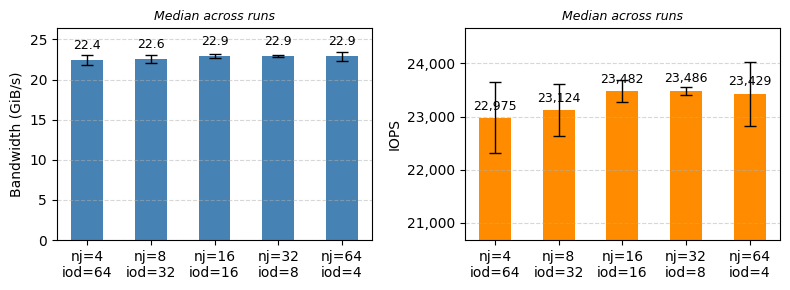

In [4]:
df = df_median  # alias for plot cells below

bw_std  = df_stats["bw_GiBs_std"].values
iops_std = df_stats["iops_std"].values

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].bar(df["label"], df["bw_GiBs"], color="steelblue", width=0.5,
            yerr=bw_std, capsize=4, error_kw=dict(elinewidth=1, ecolor="black", capthick=1))
axes[0].set_ylabel("Bandwidth (GiB/s)")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[0].set_ylim(0, df["bw_GiBs"].max() * 1.15)
for bar, v in zip(axes[0].patches, df["bw_GiBs"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{v:,.1f}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Median across runs", fontsize=9, style="italic")

axes[1].bar(df["label"], df["iops"], color="darkorange", width=0.5,
            yerr=iops_std, capsize=4, error_kw=dict(elinewidth=1, ecolor="black", capthick=1))
axes[1].set_ylabel("IOPS")
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
axes[1].set_ylim(df["iops"].min() * 0.9, df["iops"].max() * 1.05)
for bar, v in zip(axes[1].patches, df["iops"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{v:,.0f}", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Median across runs", fontsize=9, style="italic")

for ax in axes:
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bw_iops.pdf", dpi=150)
plt.show()

## Latency Plot

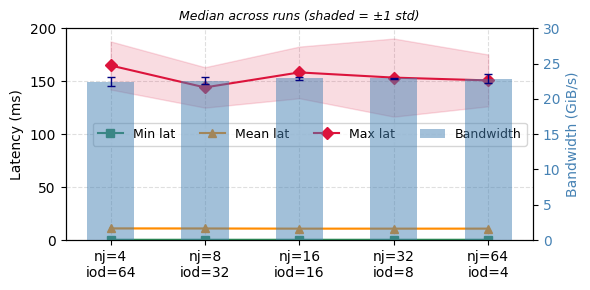

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))

# --- right axis: bandwidth bars with std error bars ---
ax2 = ax.twinx()
ax2.bar(range(len(df)), df["bw_GiBs"], color="steelblue", alpha=0.5, width=0.5, zorder=1,
        yerr=df_stats["bw_GiBs_std"].values, capsize=3,
        error_kw=dict(elinewidth=1, ecolor="navy", capthick=1))
ax2.set_ylabel("Bandwidth (GiB/s)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 30)

# --- left axis: latency lines (median) with std bands ---
x = range(len(df))
for col, label, color, marker in [
    ("lat_min_ms",  "Min lat",  "seagreen",   "s"),
    ("lat_mean_ms", "Mean lat", "darkorange",  "^"),
    ("lat_max_ms",  "Max lat",  "crimson",     "D"),
]:
    std = df_stats[f"{col}_std"].values
    ax.plot(x, df[col], f"{marker}-", label=label, color=color, zorder=3)
    ax.fill_between(x, df[col] - std, df[col] + std, alpha=0.15, color=color, zorder=2)
ax.set_ylim(0, 200)

ax.set_xticks(list(x))
ax.set_xticklabels(df["label"])
ax.set_ylabel("Latency (ms)")
ax.set_title("Median across runs (shaded = ±1 std)", fontsize=9, style="italic")
ax.grid(linestyle="--", alpha=0.4, zorder=0)

lines, labels = ax.get_legend_handles_labels()
from matplotlib.patches import Patch
lines.append(Patch(facecolor="steelblue", alpha=0.5))
labels.append("Bandwidth")
ax.legend(lines, labels, loc="best", ncols=4, fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "latency.pdf", dpi=150)
plt.show()

## Tail Latency Detail

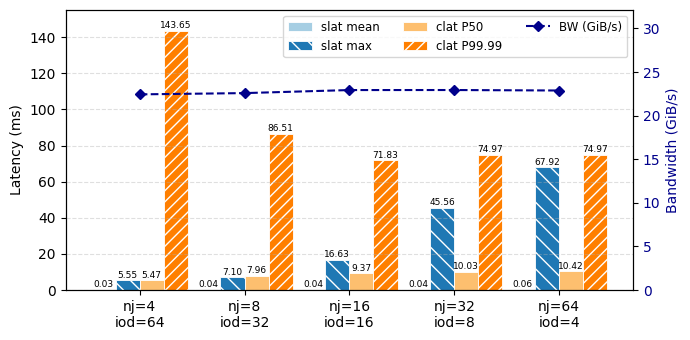

In [20]:
import matplotlib
_paired = matplotlib.colormaps["Paired"].colors
COLORS  = [_paired[0], _paired[1], _paired[6], _paired[7]]
HATCHES = ["", "\\\\", "", "///"]

metrics = [
    ("slat_mean_ms",    "slat mean"),
    ("slat_max_ms",     "slat max"),
    ("clat_50th_ms",    "clat P50"),
    ("clat_99_99th_ms", "clat P99.99"),
]
n  = len(metrics)
w  = 0.92 / n
x  = list(range(len(df)))
offsets = [(i - (n - 1) / 2) * w for i in range(n)]

fig, ax = plt.subplots(figsize=(7, 3.5))

for (col, label), offset, color, hatch in zip(metrics, offsets, COLORS, HATCHES):
    errs = df_stats[f"{col}_std"].values
    bars = ax.bar([xi + offset for xi in x], df[col], w,
                  label=label, color=color, hatch=hatch,
                  edgecolor="white", linewidth=0.6,
                #   yerr=errs, 
                  capsize=3,
                  error_kw=dict(elinewidth=0.8, ecolor="gray", capthick=0.8))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{bar.get_height():.2f}", ha="center", va="bottom",
                fontsize=6.5, rotation=0)

# --- right axis: bandwidth line (median) ---
ax2 = ax.twinx()
ax2.plot(x, df["bw_GiBs"], "D--", color="darkblue", linewidth=1.5,
         markersize=5, label="BW (GiB/s)", zorder=5)
ax2.set_ylabel("Bandwidth (GiB/s)", color="darkblue")
ax2.tick_params(axis="y", labelcolor="darkblue")
ax2.set_ylim(0, df["bw_GiBs"].max() * 1.4)

ax.set_xticks(x)
ax.set_xticklabels(df["label"])
ax.set_ylabel("Latency (ms)")
ax.set_ylim([0, 155])
# ax.set_title("Median across runs (error bars = std)", fontsize=9, style="italic")
ax.grid(axis="y", linestyle="--", alpha=0.4)

bar_handles, bar_labels = ax.get_legend_handles_labels()
line_handles, line_labels = ax2.get_legend_handles_labels()
ax.legend(bar_handles + line_handles, bar_labels + line_labels,
          ncol=3, loc="upper right", fontsize=8.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fio-tail_latency_breakdown.pdf", dpi=150)
plt.show()

## Submit Batch Size

In [7]:
# Use one representative file per config (these distributions are deterministic across runs)
rep_files = {
    (nj, iod): sorted(RESULTS_DIR.glob(f"fio_bs1M_nj{nj}_iod{iod}_*.json"))[0]
    for nj, iod in df_median[["numjobs", "iodepth"]].itertuples(index=False)
}

submit_rows = []
for (nj, iod), f in sorted(rep_files.items()):
    with open(f) as fh:
        d = json.load(fh)
    submit = d["jobs"][0]["iodepth_submit"]
    submit_rows.append({"numjobs": nj, "iodepth": iod, **{f"submit_{k}": v for k, v in submit.items()}})

df_submit = pd.DataFrame(submit_rows).sort_values("numjobs").reset_index(drop=True)
df_submit

,numjobs,iodepth,submit_0,submit_4,submit_8,submit_16,submit_32,submit_64,submit_>=64
0,4,64,0.0,100.0,0.0,0.0,0.0,0.0,0.0
1,8,32,0.0,100.0,0.0,0.0,0.0,0.0,0.0
2,16,16,0.0,100.0,0.0,0.0,0.0,0.0,0.0
3,32,8,0.0,100.0,0.0,0.0,0.0,0.0,0.0
4,64,4,0.0,100.0,0.0,0.0,0.0,0.0,0.0


Across all configurations, `iodepth_submit["4"] = 100%` regardless of the configured `iodepth` (4, 8, 16, 32, or 64). This is a fixed behavior of the DAOS DFS ioengine: it submits IOs in batches of 4 internally (via `daos_eq_poll` or equivalent), so the submit batch size never reflects the configured iodepth. The configured `iodepth` only controls the maximum number of IOs allowed in-flight simultaneously — not how many are issued per submission call.

## Queue Depth Utilization (iodepth_level)

In [8]:
level_rows = []
for (nj, iod), f in sorted(rep_files.items()):
    with open(f) as fh:
        d = json.load(fh)
    level = d["jobs"][0]["iodepth_level"]
    level_rows.append({"numjobs": nj, "iodepth": iod, **{f"level_{k}": v for k, v in level.items()}})

df_level = pd.DataFrame(level_rows).sort_values("numjobs").reset_index(drop=True)
df_level

,numjobs,iodepth,level_1,level_2,level_4,level_8,level_16,level_32,level_>=64
0,4,64,0.1,0.1,0.100000,0.100000,0.100000,0.100000,99.980969
1,8,32,0.1,0.1,0.100000,0.100000,0.100000,99.981748,0.000000
2,16,16,0.1,0.1,0.100000,0.100000,99.982998,0.000000,0.000000
3,32,8,0.1,0.1,0.100000,99.983949,0.000000,0.000000,0.000000
4,64,4,0.1,0.1,99.986375,0.000000,0.000000,0.000000,0.000000


All configurations keep the queue nearly full at their configured iodepth (~99.98–100% of the time), confirming the workload is genuinely saturating each job's queue. The small residual at lower levels (≤0.1%) corresponds to ramp-up and cooldown at the start/end of each 60 s run.

## CPU Usage (usr / sys)

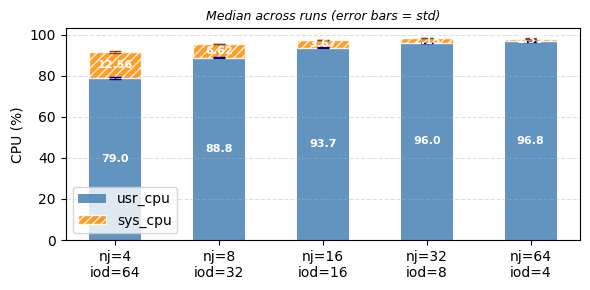

In [9]:
df_cpu = df_median[["numjobs", "iodepth", "usr_cpu", "sys_cpu", "label"]].copy()
usr_std = df_stats["usr_cpu_std"].values
sys_std = df_stats["sys_cpu_std"].values

x = list(range(len(df_cpu)))
w = 0.5
fig, ax = plt.subplots(figsize=(6, 3))

bars_usr = ax.bar(x, df_cpu["usr_cpu"], w,
                  label="usr_cpu", color="steelblue", alpha=0.85,
                  yerr=usr_std, capsize=4,
                  error_kw=dict(elinewidth=1, ecolor="navy", capthick=1))
bars_sys = ax.bar(x, df_cpu["sys_cpu"], w,
                  bottom=df_cpu["usr_cpu"],
                  label="sys_cpu", color="darkorange", alpha=0.85,
                  hatch="////", edgecolor="white",
                  yerr=sys_std, capsize=4,
                  error_kw=dict(elinewidth=1, ecolor="saddlebrown", capthick=1))

for bar_u, uv, sv in zip(bars_usr, df_cpu["usr_cpu"], df_cpu["sys_cpu"]):
    cx = bar_u.get_x() + bar_u.get_width() / 2
    ax.text(cx, uv / 2, f"{uv:.1f}",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.text(cx, uv + sv / 2, f"{sv:.2f}",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(df_cpu["label"])
ax.set_ylabel("CPU (%)")
ax.set_title("Median across runs (error bars = std)", fontsize=9, style="italic")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cpu_usage.pdf", dpi=150)
plt.show()

## Claude Key Findings

**Workload:** `rand_write`, bs=1M, total queue depth fixed at 256 (numjobs × iodepth = 256)

### 1. Bandwidth is flat across configurations
Write bandwidth is consistently regardless of how queue depth is split. The nj=4/iod=64 configuration is weakest (~21.5 GiB/s); all others exceed 22.1 GiB/s. The DFS backend is not bandwidth-limited by queue depth distribution at this scale.

### 2. Tail latency degrades sharply with deep per-job iodepth
p99 completion latency drops dramatically as iodepth per job decreases:
- **nj=4, iod=64:** clat p99 = 103 ms, p99.99 = 150 ms — worst configuration
- **nj=64, iod=4:** clat p99 = 20 ms, p99.99 = 59 ms — ~5× better p99

High per-job iodepth causes intra-job queuing that inflates tail latencies without bandwidth gains.

### 3. Mean latency is deceptively stable
Mean latency varies only 10.8–11.5 ms across all configurations, masking large tail differences. p50 latency is more informative: it rises from 5.6 ms (nj=4) to 10.4 ms (nj=64), reflecting the latency distribution shift.

### 4. Sweet spot: nj=32 or nj=64 with low iodepth
Both nj=32/iod=8 and nj=64/iod=4 achieve the best tail latency (p99 ~20 ms, p99.9 ~30 ms) with competitive bandwidth. Between them, **nj=32/iod=8** has lower p99.99 (49.6 ms vs 59.0 ms), making it the best balanced configuration.

**Recommendation:** For 1M write workloads on DAOS DFS with total QD=256, prefer more jobs with lower per-job iodepth (nj=32–64, iod=4–8). This minimizes tail latency with no meaningful bandwidth cost. 